In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/Disaster_dataset.csv", sep=";")

print(df.head())

   Year     Country  ISO Disaster Group Disaster Subroup      Disaster Type  \
0  1900  Cabo Verde  CPV        Natural   Climatological            Drought   
1  1900       India  IND        Natural   Climatological            Drought   
2  1900     Jamaica  JAM        Natural     Hydrological              Flood   
3  1900       Japan  JPN        Natural      Geophysical  Volcanic activity   
4  1900      Turkey  TUR        Natural      Geophysical         Earthquake   

  Disaster Subtype  Total Events  Total Affected  Total Deaths  \
0          Drought             1             NaN       11000.0   
1          Drought             1             NaN     1250000.0   
2              NaN             1             NaN         300.0   
3         Ash fall             1             NaN          30.0   
4  Ground movement             1             NaN         140.0   

   Total Damage (USD, original)  Total Damage (USD, adjusted)              CPI  
0                           NaN                

In [3]:
print("Dataset Shape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

print("\nStatistical Summary")
print(df.describe())

Dataset Shape
(10431, 13)

Data Types
Year                              int64
Country                             str
ISO                                 str
Disaster Group                      str
Disaster Subroup                    str
Disaster Type                       str
Disaster Subtype                    str
Total Events                      int64
Total Affected                  float64
Total Deaths                    float64
Total Damage (USD, original)    float64
Total Damage (USD, adjusted)    float64
CPI                                 str
dtype: object

Statistical Summary
               Year  Total Events  Total Affected  Total Deaths  \
count  10431.000000  10431.000000    7.586000e+03  7.375000e+03   
mean    1995.609625      1.446649    1.125969e+06  3.107711e+03   
std       22.001186      1.246589    9.760891e+06  7.255589e+04   
min     1900.000000      1.000000    1.000000e+00  1.000000e+00   
25%     1986.000000      1.000000    1.200000e+03  6.000000e+00   
50%  

In [4]:
high_death = df.sort_values(
    by="Total Deaths",
    ascending=False
)

print("Disasters with Highest Deaths")
print(
    high_death[
        ["Year", "Country", "Disaster Type", "Total Deaths"]
    ].head(10)
)

Disasters with Highest Deaths
     Year       Country Disaster Type  Total Deaths
242  1931         China         Flood     3700000.0
203  1928         China       Drought     3000000.0
694  1959         China         Flood     2000187.0
370  1943    Bangladesh       Drought     1900000.0
910  1965         India       Drought     1500000.0
366  1942         India       Drought     1500000.0
1    1900         India       Drought     1250000.0
142  1921  Soviet Union       Drought     1200000.0
135  1920         China       Drought      500000.0
324  1939         China         Flood      500000.0


In [5]:
india = df[df["Country"] == "India"]

print("Disasters in India")
print(india.head(10))

Disasters in India
     Year Country  ISO Disaster Group Disaster Subroup Disaster Type  \
1    1900   India  IND        Natural   Climatological       Drought   
30   1905   India  IND        Natural      Geophysical    Earthquake   
115  1916   India  IND        Natural   Meteorological         Storm   
164  1924   India  IND        Natural   Meteorological         Storm   
169  1925   India  IND        Natural   Meteorological         Storm   
184  1926   India  IND        Natural     Hydrological         Flood   
194  1927   India  IND        Natural   Meteorological         Storm   
207  1928   India  IND        Natural     Hydrological         Flood   
282  1935   India  IND        Natural   Meteorological         Storm   
283  1935   India  IND        Natural   Meteorological         Storm   

     Disaster Subtype  Total Events  Total Affected  Total Deaths  \
1             Drought             1             NaN     1250000.0   
30    Ground movement             1             Na

In [6]:
sorted_damage = df.sort_values(
    by="Total Damage (USD, adjusted)",
    ascending=False
)

print("Top Disasters by Economic Damage")

print(
    sorted_damage[
        [
            "Year",
            "Country",
            "Disaster Type",
            "Total Damage (USD, adjusted)"
        ]
    ].head(10)
)

Top Disasters by Economic Damage
       Year                         Country Disaster Type  \
7787   2011                           Japan    Earthquake   
6485   2005  United States of America (the)         Storm   
3987   1995                           Japan    Earthquake   
9163   2017  United States of America (the)         Storm   
7033   2008                           China    Earthquake   
10364  2022  United States of America (the)         Storm   
6196   2004  United States of America (the)         Storm   
9126   2017                     Puerto Rico         Storm   
10124  2021  United States of America (the)         Storm   
1881   1980                           Italy    Earthquake   

       Total Damage (USD, adjusted)  
7787                   2.732184e+11  
6485                   2.360670e+11  
3987                   1.920518e+11  
9163                   1.817753e+11  
7033                   1.162070e+11  
10364                  1.010000e+11  
6196                   8.2214

In [7]:
print("Mean Deaths:", df["Total Deaths"].mean())

print("Median Deaths:", df["Total Deaths"].median())

print("Mode Deaths:")
print(df["Total Deaths"].mode())

print("Standard Deviation:", df["Total Deaths"].std())

Mean Deaths: 3107.7106440677967
Median Deaths: 23.0
Mode Deaths:
0    1.0
Name: Total Deaths, dtype: float64
Standard Deviation: 72555.88568379164


In [8]:
country_deaths = (
    df.groupby("Country")["Total Deaths"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top Countries by Average Deaths")
print(country_deaths)

Top Countries by Average Deaths
Country
Soviet Union    46807.689655
China           32816.431138
India           13545.005900
Bangladesh      12456.543269
Cabo Verde       9449.444444
Ethiopia         9199.522727
Sudan (the)      4461.264706
Haiti            3408.763889
Martinique       3342.555556
Niger (the)      3068.285714
Name: Total Deaths, dtype: float64


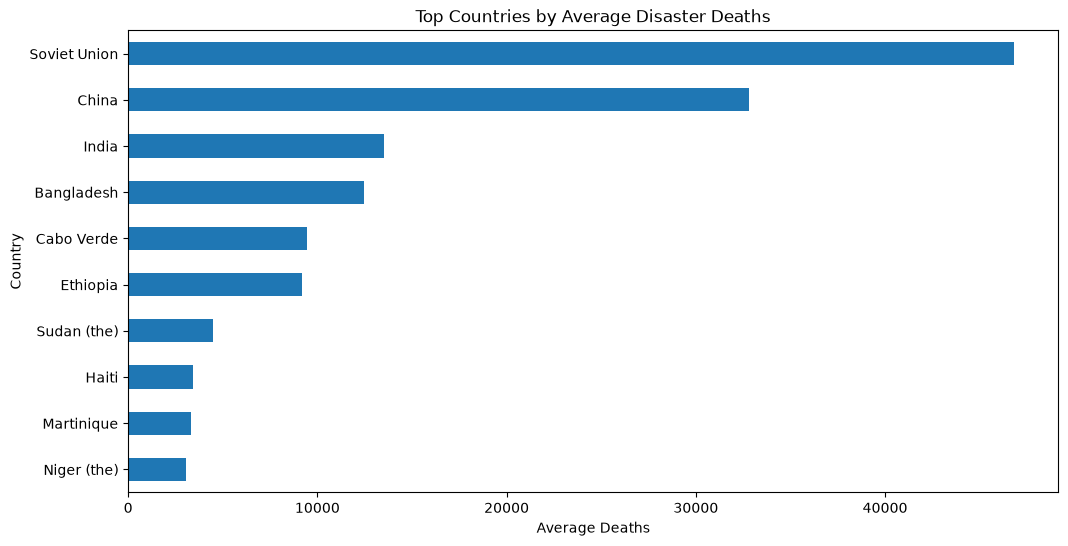

In [9]:
plt.figure(figsize=(12, 6))

country_deaths.sort_values().plot(
    kind="barh"
)

plt.title("Top Countries by Average Disaster Deaths")
plt.xlabel("Average Deaths")
plt.ylabel("Country")

plt.show()

In [ ]:
corr = df[
    [
        "Total Events",
        "Total Affected",
        "Total Deaths",
        "Total Damage (USD, original)",
        "Total Damage (USD, adjusted)",
        "CPI"
    ]
].copy()

corr["CPI"] = pd.to_numeric(corr["CPI"].astype(str).str.replace(",", "."), errors='coerce')

corr = corr.corr()

print("Correlation Matrix")
print(corr)

ValueError: could not convert string to float: '2,8490844088613'